# Optimal Transport on 2D Grid with Obstacles

This notebook demonstrates the Flow Sinkhorn algorithm on a **2D regular grid** with **cost modulation** by Gaussian bumps.

We will:
1. Create a 30×30 square grid graph
2. Modulate edge costs with two Gaussian bumps (obstacles)
3. Place source at top-left and sink at bottom-right
4. Compute exact optimal transport using linear programming
5. Compute approximate transport using Flow Sinkhorn
6. Visualize how the flow avoids high-cost regions (obstacles)

This example illustrates **obstacle avoidance** in optimal transport.

In [1]:
# Install Flow Sinkhorn from GitHub (for Colab)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print('Running on Colab - installing flowsinkhorn from GitHub...')
    !pip install -q -e ..
    !pip install -q sparse
    print('Installation complete!')

else:
    print('Running locally - using local flowsinkhorn')
    import sys
    from pathlib import Path

    cwd = Path.cwd().resolve()
    repo_root = cwd.parent if cwd.name == 'examples' else cwd
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))

Running locally - using local flowsinkhorn


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import time
import warnings

# Import Flow Sinkhorn toolbox
from flowsinkhorn import sinkhorn_w1_sparse, solve_w1_exact
from flowsinkhorn.toolbox import (
    create_grid_graph,
    compute_modulated_costs,
    create_corner_sources_sinks,
    plot_grid_with_costs,
    plot_grid_with_flow,
)
import sparse

warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 10)


## 1. Create 2D Square Grid

We create a regular grid graph:
- Grid size: 30×30 = 900 vertices
- Each vertex connected to 4 neighbors (up, down, left, right)
- Vertices at position (i, j) with i, j ∈ {0, 1, ..., 29}

In [3]:
# Create grid
grid_size = 20
positions, A, edges = create_grid_graph(grid_size)
n_vertices = len(positions)
n_edges = len(edges)

print(f"Grid created:")
print(f"  - Grid size: {grid_size}×{grid_size}")
print(f"  - {n_vertices} vertices")
print(f"  - {n_edges} edges")
print(f"  - Average degree: {A.sum() / n_vertices:.1f}")

Grid created:
  - Grid size: 20×20
  - 400 vertices
  - 760 edges
  - Average degree: 3.8


## 2. Add Gaussian Bumps as Obstacles

We create two Gaussian bumps in the middle of the grid to modulate edge costs.

For each edge, we compute:
$$
W_{ij} = 1 + \alpha \cdot \left( g_1(\text{midpoint}) + g_2(\text{midpoint}) \right)
$$

where $g_k$ are Gaussian functions centered at specific locations.

This creates **high-cost regions** that the optimal transport will tend to avoid.

In [36]:
# Define two smaller and more separated Gaussian bumps
centers = [
    (grid_size * 0.45, grid_size * 0.45),  # Left bump
    (grid_size * 0.1, grid_size * 0.8),  # Right bump
    (grid_size * 0.8, grid_size * 0.1),
]
sigmas = [2.5, 2.5, 1.5]  # Smaller bumps
alpha = 10.0  # Raw modulation amplitude before normalization

W, cost_field = compute_modulated_costs(positions, A, edges, centers, sigmas, alpha)

# Normalize edge weights to the target range [1, 5]
edge_mask = A > 0
edge_weights = W[edge_mask]
w_min, w_max = edge_weights.min(), edge_weights.max()
if w_max > w_min:
    W[edge_mask] = 1.0 + 2.0 * (edge_weights - w_min) / (w_max - w_min)
else:
    W[edge_mask] = 1.0
W[~edge_mask] = 1e9
np.fill_diagonal(W, 0)

print(f"Cost modulation:")
print(f"  - Number of bumps: {len(centers)}")
print(f"  - Bump centers: {centers}")
print(f"  - Sigmas: {sigmas}")
print(f"  - Raw amplitude α: {alpha}")
print(f"  - Edge weight range target: [1, 5]")
print(f"  - Min edge cost: {W[A > 0].min():.4f}")
print(f"  - Max edge cost: {W[A > 0].max():.4f}")
print(f"  - Mean edge cost: {W[A > 0].mean():.4f}")

Cost modulation:
  - Number of bumps: 3
  - Bump centers: [(9.0, 9.0), (2.0, 16.0), (16.0, 2.0)]
  - Sigmas: [2.5, 2.5, 1.5]
  - Raw amplitude α: 10.0
  - Edge weight range target: [1, 5]
  - Min edge cost: 1.0000
  - Max edge cost: 3.0000
  - Mean edge cost: 1.4358


## 3. Visualize Grid and Cost Field

Display the grid with the cost field (Gaussian bumps) as a heatmap.

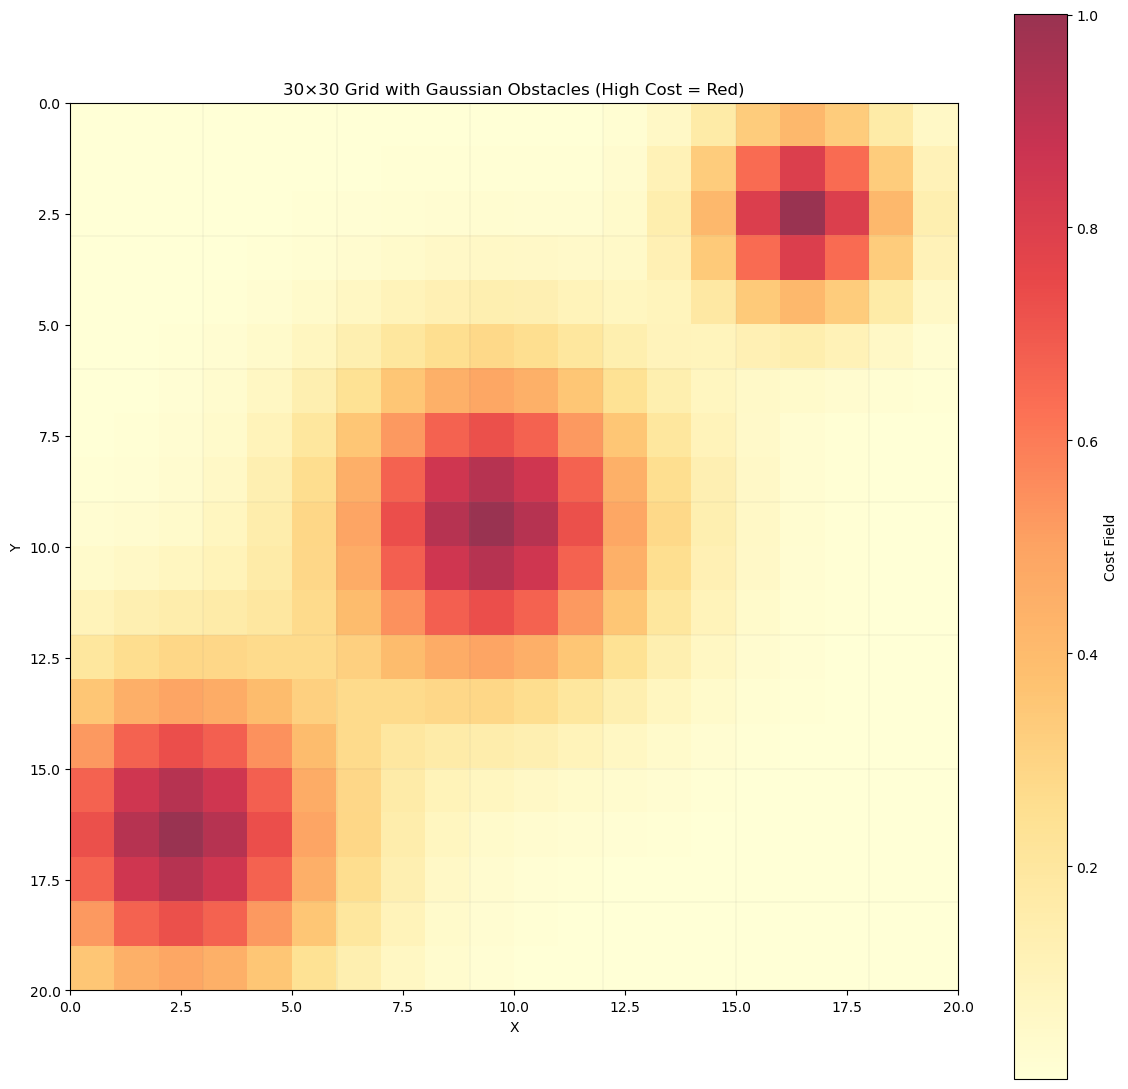

In [37]:
plot_grid_with_costs(
    positions,
    cost_field,
    grid_size,
    title="30×30 Grid with Gaussian Obstacles (High Cost = Red)",
)

## 4. Define Source and Sink

- **Source**: Top-left corner (vertex 0)
- **Sink**: Bottom-right corner (vertex n²-1)

The optimal transport will find the best path from top-left to bottom-right, avoiding the high-cost regions.

Source and sink:
  - Source index: 0 at position [0. 0.]
  - Sink index: 399 at position [19. 19.]
  - Euclidean distance: 26.87


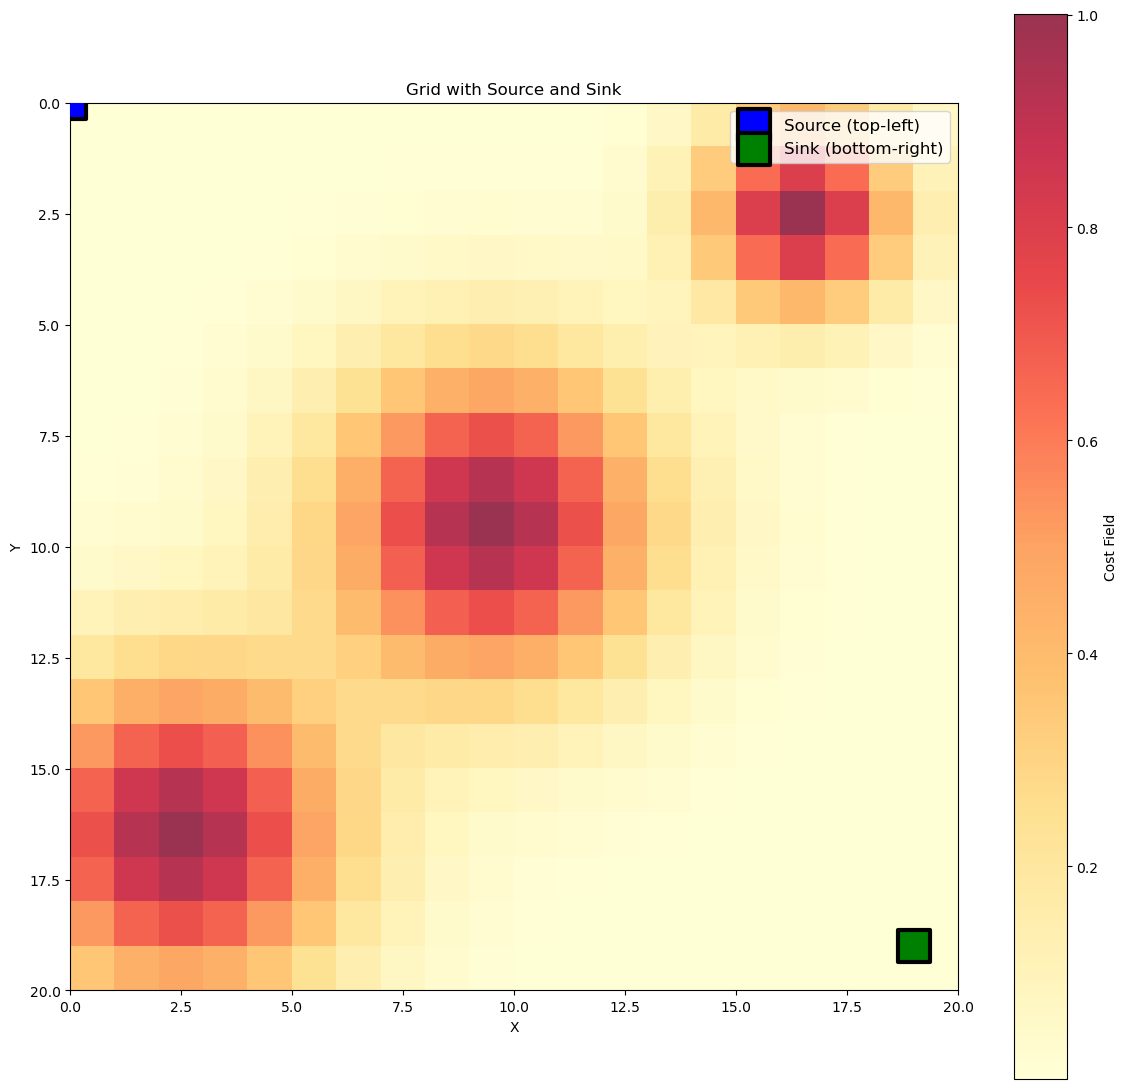

In [38]:
source_idx, sink_idx, z = create_corner_sources_sinks(grid_size)

print(f"Source and sink:")
print(f"  - Source index: {source_idx} at position {positions[source_idx]}")
print(f"  - Sink index: {sink_idx} at position {positions[sink_idx]}")
print(f"  - Euclidean distance: {np.linalg.norm(positions[source_idx] - positions[sink_idx]):.2f}")

# Visualize source and sink
cost_grid = cost_field.reshape(grid_size, grid_size)
fig, ax = plt.subplots(figsize=(12, 11))
im = ax.imshow(cost_grid, cmap='YlOrRd', origin='upper', 
               extent=[0, grid_size, grid_size, 0], alpha=0.8)
plt.colorbar(im, ax=ax, label='Cost Field')

# Plot source and sink
ax.scatter(positions[source_idx, 0], positions[source_idx, 1], 
          s=500, c='blue', marker='s', edgecolors='black', linewidths=3,
          label='Source (top-left)', zorder=10)
ax.scatter(positions[sink_idx, 0], positions[sink_idx, 1], 
          s=500, c='green', marker='s', edgecolors='black', linewidths=3,
          label='Sink (bottom-right)', zorder=10)

ax.set_xlim(0, grid_size)
ax.set_ylim(grid_size, 0)
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_title('Grid with Source and Sink')
ax.legend(fontsize=12, loc='upper right')
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

## 5. Exact Optimal Transport (Linear Programming)

Compute the exact optimal transport using CVXPY.

**Note**: For a 900-vertex graph, this may take some time (~10-60 seconds depending on the solver).

In [39]:
print("Computing exact optimal transport...")
print("(This may take 10-60 seconds for a 900-vertex graph)\n")

start = time.time()
F_exact, obj_exact, status = solve_w1_exact(W, z, verbose=False)
time_exact = time.time() - start

print(f"Exact solver:")
print(f"  - Status: {status}")
print(f"  - Optimal cost: {obj_exact:.6f}")
print(f"  - Time: {time_exact:.2f}s")
print(f"  - Non-zero flows: {np.sum(F_exact > 1e-6)}")

Computing exact optimal transport...
(This may take 10-60 seconds for a 900-vertex graph)

Exact solver:
  - Status: optimal
  - Optimal cost: 46.154542
  - Time: 1.60s
  - Non-zero flows: 586


## 6. Visualize Exact Flow

Display the exact optimal transport flow on the grid.

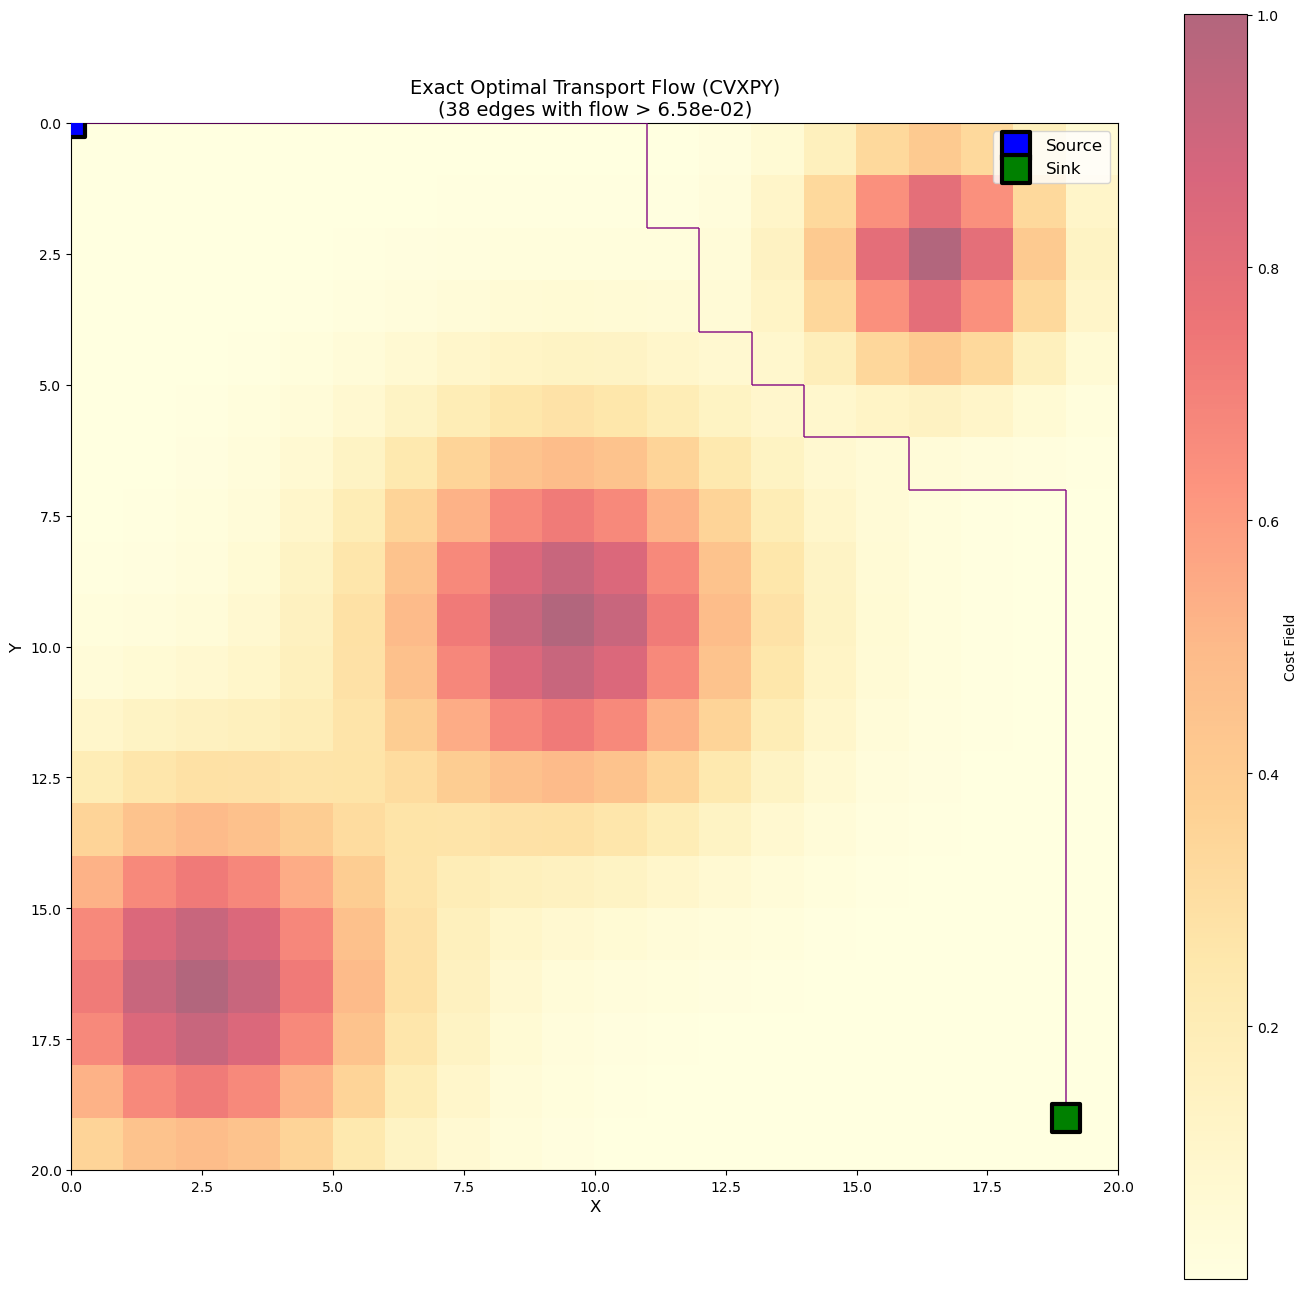

In [40]:
# Visualize exact flow
threshold_exact = F_exact.max() / 100
plot_grid_with_flow(positions, cost_field, F_exact, z, grid_size,
                    threshold=threshold_exact,
                    title="Exact Optimal Transport Flow (CVXPY)",
                    flow_color='purple',
                    flow_width_scale=8)

## 7. Flow Sinkhorn with Large Regularization

Use a large entropic regularization parameter for faster convergence.

In [47]:
# Create sparse cost matrix
Ws = sparse.COO(A.nonzero(), W[A.nonzero()], shape=W.shape, fill_value=1e9)

# Large regularization
epsilon_large = 0.1
niter = 4000

print(f"Computing Sinkhorn flow with large regularization (ε = {epsilon_large})...")
start = time.time()
F_sinkhorn_large, err_large, h_large = sinkhorn_w1_sparse(Ws, z, epsilon=epsilon_large, niter=niter)
time_sinkhorn_large = time.time() - start

# Convert to dense
F_sinkhorn_large_dense = F_sinkhorn_large.todense()

# Compute cost
cost_large = np.sum(F_sinkhorn_large_dense * W)

print(f"\nSinkhorn (large ε):")
print(f"  - Final error: {err_large[-1]:.2e}")
print(f"  - Cost: {cost_large:.6f}")
print(f"  - Relative cost error: {abs(cost_large - obj_exact) / obj_exact * 100:.2f}%")
print(f"  - Time: {time_sinkhorn_large:.2f}s")
print(f"  - Speedup vs exact: {time_exact / time_sinkhorn_large:.1f}x")

Computing Sinkhorn flow with large regularization (ε = 0.1)...

Sinkhorn (large ε):
  - Final error: 2.54e-02
  - Cost: 40.799061
  - Relative cost error: 11.60%
  - Time: 8.54s
  - Speedup vs exact: 0.2x


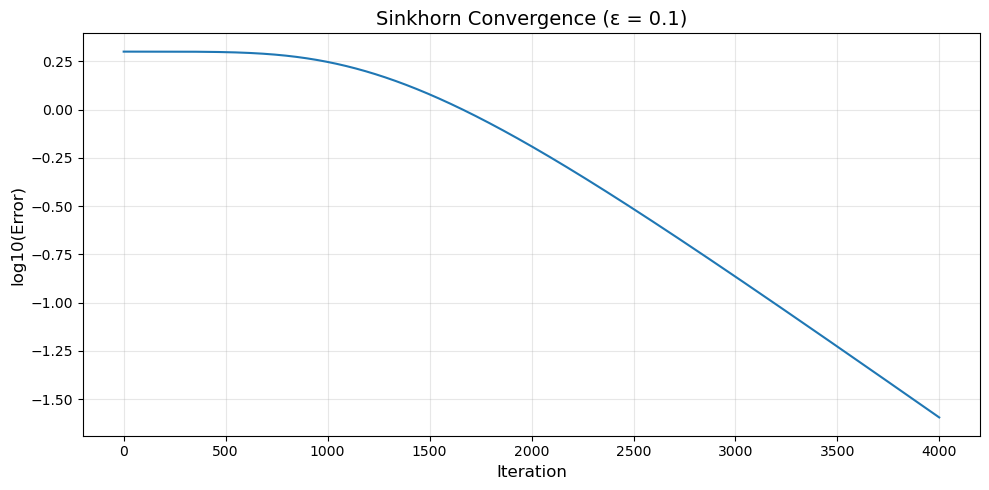

In [48]:
# Plot convergence
plt.figure(figsize=(10, 5))
plt.plot(np.log10(err_large))
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('log10(Error)', fontsize=12)
plt.title(f'Sinkhorn Convergence (ε = {epsilon_large})', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

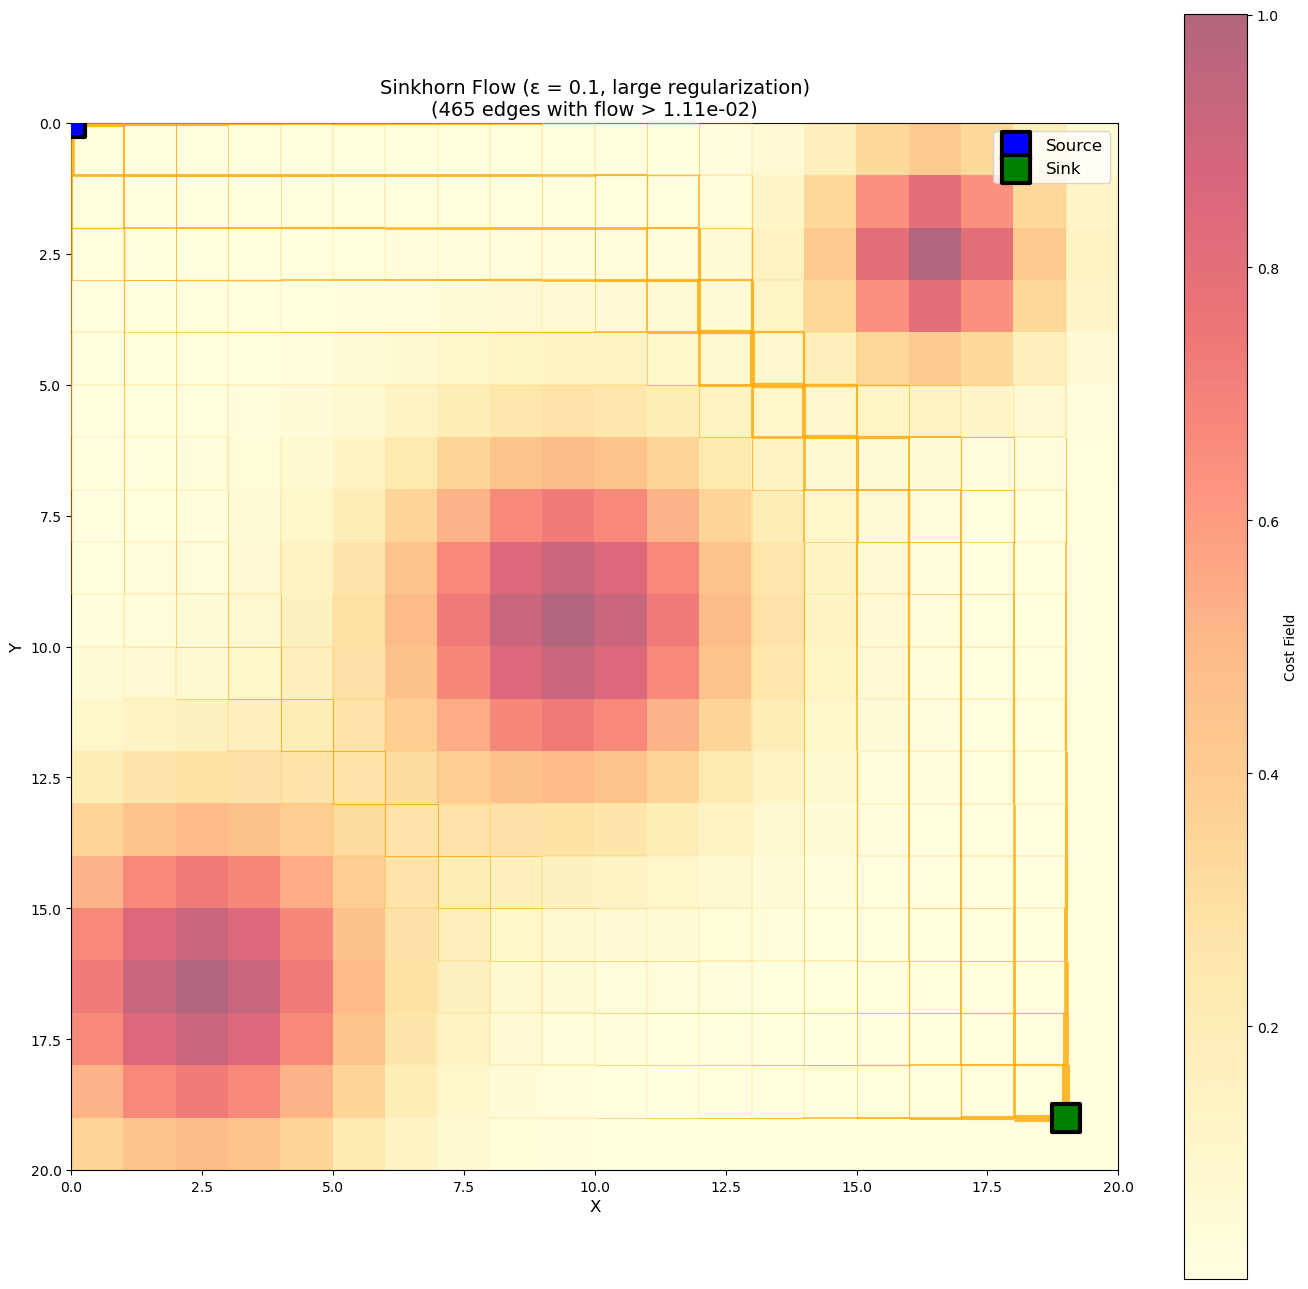

In [49]:
# Visualize flow
threshold_large = F_sinkhorn_large_dense.max() / 50
plot_grid_with_flow(positions, cost_field, F_sinkhorn_large_dense, z, grid_size,
                    threshold=threshold_large,
                    title=f"Sinkhorn Flow (ε = {epsilon_large}, large regularization)",
                    flow_color='orange',
                    flow_width_scale=6)

## 8. Flow Sinkhorn with Small Regularization

Use a smaller ε to get closer to the exact solution.

In [50]:
# Small regularization
epsilon_small = 0.05
niter = 5000

print(f"Computing Sinkhorn flow with small regularization (ε = {epsilon_small})...")
start = time.time()
F_sinkhorn_small, err_small, h_small = sinkhorn_w1_sparse(Ws, z, epsilon=epsilon_small, niter=niter)
time_sinkhorn_small = time.time() - start

# Convert to dense
F_sinkhorn_small_dense = F_sinkhorn_small.todense()

# Compute cost
cost_small = np.sum(F_sinkhorn_small_dense * W)

print(f"\nSinkhorn (small ε):")
print(f"  - Final error: {err_small[-1]:.2e}")
print(f"  - Cost: {cost_small:.6f}")
print(f"  - Relative cost error: {abs(cost_small - obj_exact) / obj_exact * 100:.2f}%")
print(f"  - Time: {time_sinkhorn_small:.2f}s")
print(f"  - Speedup vs exact: {time_exact / time_sinkhorn_small:.1f}x")

Computing Sinkhorn flow with small regularization (ε = 0.05)...

Sinkhorn (small ε):
  - Final error: 1.00e-02
  - Cost: 40.019027
  - Relative cost error: 13.29%
  - Time: 10.87s
  - Speedup vs exact: 0.1x


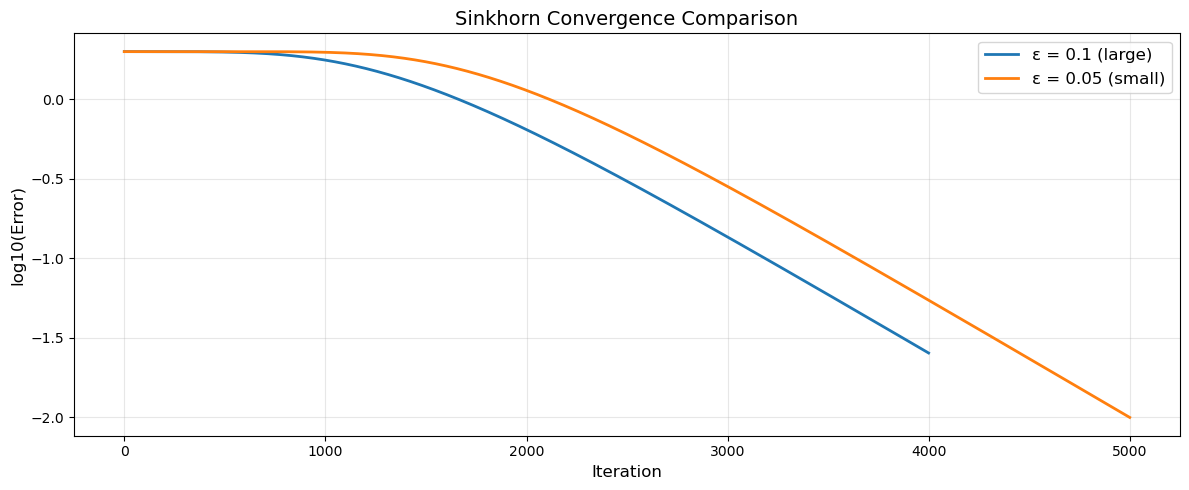

In [51]:
# Plot convergence comparison
plt.figure(figsize=(12, 5))
plt.plot(np.log10(err_large), label=f'ε = {epsilon_large} (large)', linewidth=2)
plt.plot(np.log10(err_small), label=f'ε = {epsilon_small} (small)', linewidth=2)
plt.xlabel('Iteration', fontsize=12)
plt.ylabel('log10(Error)', fontsize=12)
plt.title('Sinkhorn Convergence Comparison', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

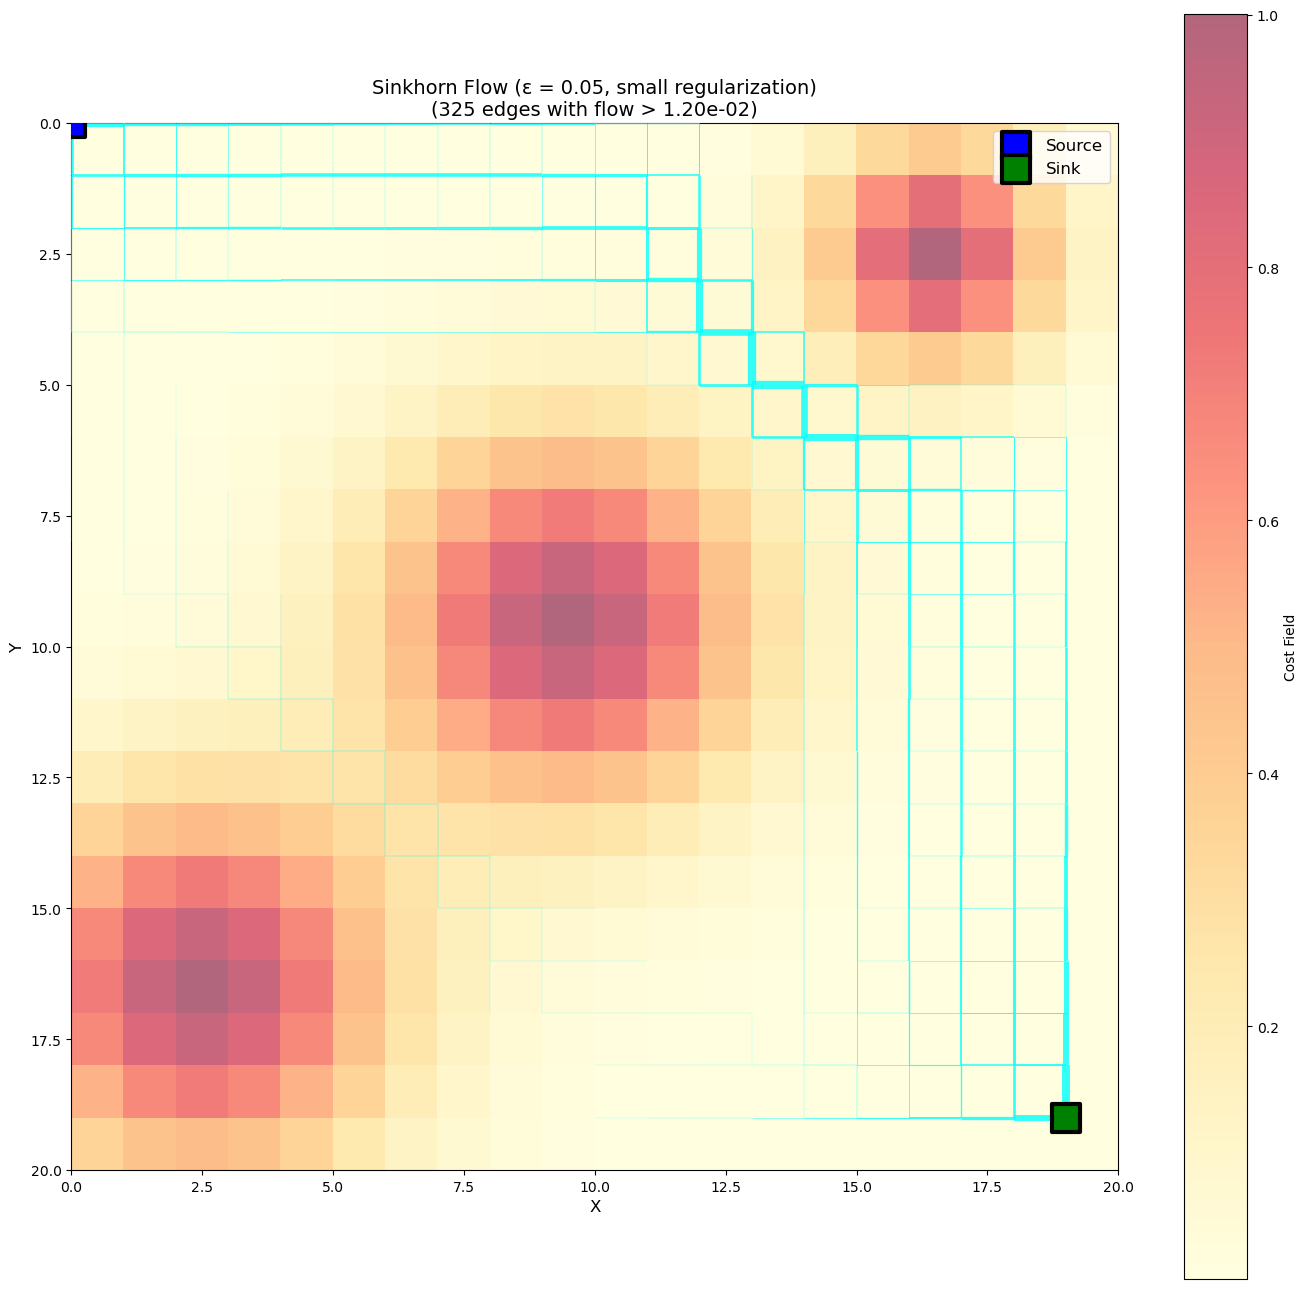

In [52]:
# Visualize flow
threshold_small = F_sinkhorn_small_dense.max() / 50
plot_grid_with_flow(positions, cost_field, F_sinkhorn_small_dense, z, grid_size,
                    threshold=threshold_small,
                    title=f"Sinkhorn Flow (ε = {epsilon_small}, small regularization)",
                    flow_color='cyan',
                    flow_width_scale=6)